# Liver Patient Dataset

In [1]:
# install kagglehub
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
# imports

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

sns.set_style('whitegrid')

### Read in the data

We are looking at liver patient data to predict if they have liver disease or not.

In [3]:
# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)
# List files in the downloaded dataset directory
print(os.listdir(path))

Path to dataset files: /home/190db20c-4766-499c-a1ba-24f399c9ac2f/.cache/kagglehub/datasets/shauryasrivastava01/liver-patient-dataset/versions/1
['liver_patient_dataset.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "liver_patient_dataset.csv"))
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


In [5]:
# replace the target variable with 1 for positive class (liver disease) and 0 for negative class (no liver disease)
df['Selector'] = df['Selector'].replace({'Liver Disease':1, 'No Liver Disease':0})

In [6]:
# change the name of the selector column to target
df.rename(columns={'Selector':'Target'}, inplace=True)
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [7]:
# calculate the prevalance
prevalance = np.mean(df.Target) * 100
print(f'The prevalance is {prevalance:.2f}%')

The prevalance is 71.36%


In [8]:
# check for null values
print(df.isna().sum())

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Target       0
dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Target     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [10]:
# print the summary statistics of the numeric data
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


From looking at the summary statistics, TB (Total Bilirubin), DB (Direct Bilirubin), Alkphos (Alkaline Phosphotase), Sgpt (Alamine Aminotransferase), and Sgot (Aspartate Aminotransferase) all need to be transformed so they have a more normal distribution. They are all clearly very skewed, as they have standard deviations that are much greater than the means and have max values that are much higher than the number that's the 75th percentile of the column. These are all skewed to the right so we will use log transformations on the columns.

In [11]:
to_transform = ['TB',	'DB',	'Alkphos',	'Sgpt',	'Sgot']
names = ['TB_log',	'DB_log',	'Alkphos_log',	'Sgpt_log',	'Sgot_log']
df[names] = np.log(df[to_transform])
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,TB_log,DB_log,Alkphos_log,Sgpt_log,Sgot_log
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1,-0.356675,-2.302585,5.231109,2.772589,2.890372
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1,2.388763,1.704748,6.549651,4.158883,4.605170
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1,1.987874,1.410987,6.194405,4.094345,4.219508
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1,0.000000,-0.916291,5.204007,2.639057,2.995732
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1,1.360977,0.693147,5.273000,3.295837,4.077537


In [12]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,TB_log,DB_log,Alkphos_log,Sgpt_log,Sgot_log
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551,0.463421,-0.650373,5.493417,3.751829,3.956771
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490,1.018527,1.326394,0.528128,0.900236,0.997381
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000,-0.916291,-2.302585,4.143135,2.302585,2.302585
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000,-0.223144,-1.609438,5.167635,3.135494,3.218876
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000,0.000000,-1.203973,5.337538,3.555348,3.737670
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000,0.955511,0.262364,5.697093,4.102609,4.465908
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000,4.317488,2.980619,7.654443,7.600902,8.502891


# Method: Logistic Regression

We are using logistic regression as one of our methods. Model 1 will be a logistic regression model with the original numeric variables instead of the log transformations so that we can compare the two.

In [35]:
# logistic regression model with original variables
CATEGORICAL_1 = ['Gender']
NUMERIC_1     = ['TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']
TARGET_1      = 'Target'

X = df[CATEGORICAL_1 + NUMERIC_1]
y = df[TARGET_1]

# Train / Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 466 rows | Test: 117 rows


In [36]:
# Create pipeline
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), CATEGORICAL_1),
    ('num', 'passthrough', NUMERIC_1)
])

pipe_m1 = Pipeline(steps=[
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m1.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['Gender']),
                                                 ('num', 'passthrough',
                                                  ['TB', 'DB', 'Alkphos',
                                                   'Sgpt', 'Sgot', 'TP', 'ALB',
                                                   'A/G Ratio'])])),
                ('model',
                 LogisticRegression(max_iter=5000, n_jobs=-1,
                                    random_state=42))])

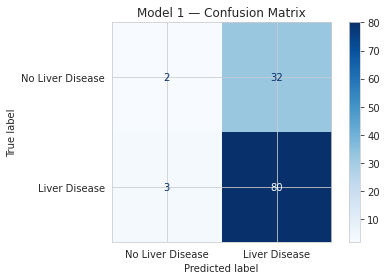

                  precision    recall  f1-score   support

No Liver Disease       0.40      0.06      0.10        34
   Liver Disease       0.71      0.96      0.82        83

        accuracy                           0.70       117
       macro avg       0.56      0.51      0.46       117
    weighted avg       0.62      0.70      0.61       117



In [37]:
# Create confusion matrix
y_pred_m1 = pipe_m1.predict(X_test)
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['No Liver Disease', 'Liver Disease'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['No Liver Disease', 'Liver Disease']))

The confusion matrix has a very high number of false positives. 32 patients were misclassified as having liver disease when they actually didn't.

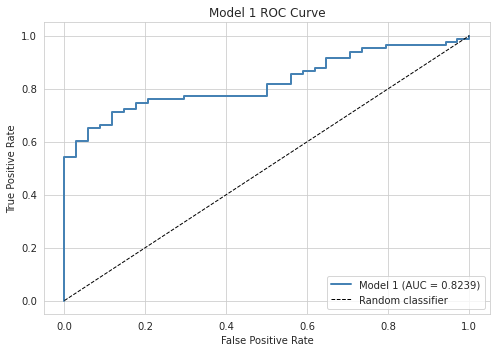

Model 1 ROC-AUC: 0.8239


In [38]:
# ROC Curve

y_proba_m1 = pipe_m1.predict_proba(X_test)[:, 1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

The Model 1 ROC Curve shows that it has an ROC value of 0.8239, which isn't perfect, but pretty good. We'll make a second model with the log-transformed values to see if it changes anything.

In [39]:
# Now, we'll try it with the log-transformed variables in a new model
CATEGORICAL_2 = ['Gender']
NUMERIC_2     = ['TB_log', 'DB_log', 'Alkphos_log', 'Sgpt_log', 'Sgot_log', 'TP', 'ALB', 'A/G Ratio']
TARGET_2      = 'Target'

X = df[CATEGORICAL_2 + NUMERIC_2]
y = df[TARGET_2]

# Train / Test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 466 rows | Test: 117 rows


In [40]:
# Create pipeline
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), CATEGORICAL_2),
    ('num', 'passthrough', NUMERIC_2)
])

pipe_m2 = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m2.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['Gender']),
                                                 ('num', 'passthrough',
                                                  ['TB_log', 'DB_log',
                                                   'Alkphos_log', 'Sgpt_log',
                                                   'Sgot_log', 'TP', 'ALB',
                                                   'A/G Ratio'])])),
                ('model',
                 LogisticRegression(max_iter=5000, n_jobs=-1,
                                    random_state=42))])

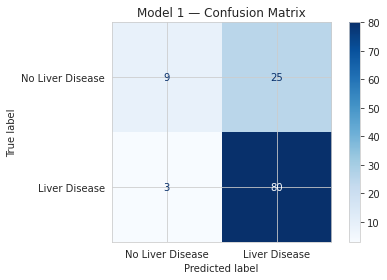

                  precision    recall  f1-score   support

No Liver Disease       0.75      0.26      0.39        34
   Liver Disease       0.76      0.96      0.85        83

        accuracy                           0.76       117
       macro avg       0.76      0.61      0.62       117
    weighted avg       0.76      0.76      0.72       117



In [41]:
# Create confusion matrix
y_pred_m2 = pipe_m2.predict(X_test)
cm_m2 = confusion_matrix(y_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['No Liver Disease', 'Liver Disease'])
disp_m2.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2, target_names=['No Liver Disease', 'Liver Disease']))

Model 2 with the log-transformed variables reduced the number of false positives. However, the number of false negatives stayed the same.

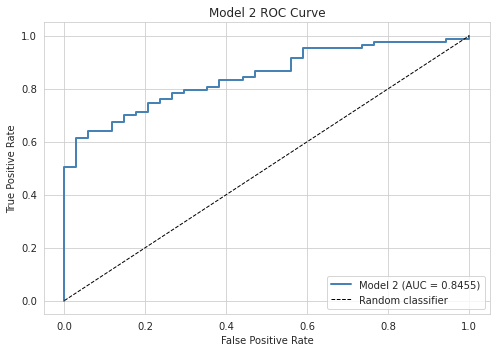

Model 2 ROC-AUC: 0.8455


In [42]:
# ROC Curve

y_proba_m2 = pipe_m2.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, thresholds = roc_curve(y_test, y_proba_m2)
auc_m2 = roc_auc_score(y_test, y_proba_m2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 ROC-AUC: {auc_m2:.4f}")

Our ROC curve improved with the log-transformed variables.

From the correlation matrix of variables in the EDA section, there were some variables that were negatively correlated with the target variable. These variables were TP (-0.035), ALB (-0.16), and A/G Ratio (-0.16). We're going to drop these for the next model and see if that affects the correlation.

In [43]:
# Create train and test without the negatively-correlated variables
CATEGORICAL_3 = ['Gender']
NUMERIC_3     = ['TB_log', 'DB_log', 'Alkphos_log', 'Sgpt_log', 'Sgot_log']
TARGET_3      = 'Target'

X = df[CATEGORICAL_3 + NUMERIC_3]
y = df[TARGET_3]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 466 rows | Test: 117 rows


In [44]:
# Create pipeline
preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), CATEGORICAL_3),
    ('num', 'passthrough', NUMERIC_3)
])

pipe_m3 = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m3.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['Gender']),
                                                 ('num', 'passthrough',
                                                  ['TB_log', 'DB_log',
                                                   'Alkphos_log', 'Sgpt_log',
                                                   'Sgot_log'])])),
                ('model',
                 LogisticRegression(max_iter=5000, n_jobs=-1,
                                    random_state=42))])

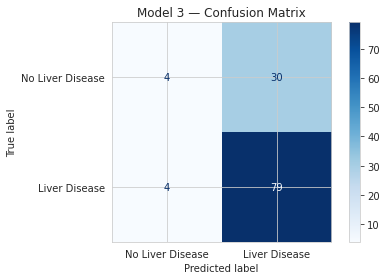

                  precision    recall  f1-score   support

No Liver Disease       0.50      0.12      0.19        34
   Liver Disease       0.72      0.95      0.82        83

        accuracy                           0.71       117
       macro avg       0.61      0.53      0.51       117
    weighted avg       0.66      0.71      0.64       117



In [45]:
# Create confusion matrix
y_pred_m3 = pipe_m3.predict(X_test)
cm_m3 = confusion_matrix(y_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['No Liver Disease', 'Liver Disease'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3, target_names=['No Liver Disease', 'Liver Disease']))

Removing the negatively-correlated variables actually increased the number of false negatives and it made the false positives much higher again. 

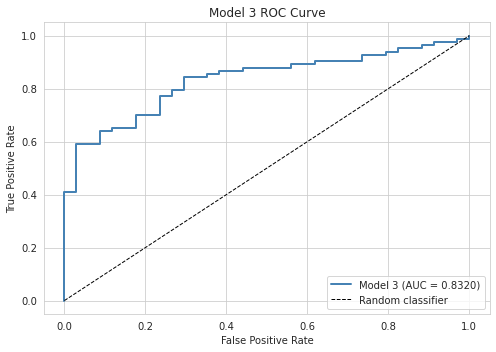

Model 3 ROC-AUC: 0.8320


In [46]:
# ROC Curve

y_proba_m3 = pipe_m3.predict_proba(X_test)[:, 1]
fpr_m3, tpr_m3, thresholds = roc_curve(y_test, y_proba_m3)
auc_m3 = roc_auc_score(y_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m3:.4f}")

Removing the negatively-correlated variables did not help our model very much. 

Thus far, Model 2 has given us the best ROC score. However, it's a pretty default model, so there are ways to improve it. Even though we applied the log transformations, the variables are not scaled, so we will scale them in the next model. Additionally, since the prevalence is 71.36%, it's imbalanced. We can balance it using class_weight = 'balanced'. 

In [47]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [48]:
# Create model 4 with scaled variables, balanced weights, and adjusted C value
CATEGORICAL_4 = ['Gender']
NUMERIC_4     = ['TB_log', 'DB_log', 'Alkphos_log', 'Sgpt_log', 'Sgot_log', 'TP', 'ALB', 'A/G Ratio']
TARGET_4      = 'Target'

X = df[CATEGORICAL_4 + NUMERIC_4]
y = df[TARGET_4]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [49]:
# One-hot encoding on categorical variable
preprocessor_m4 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), CATEGORICAL_4),
    ('num', StandardScaler(), NUMERIC_4) 
])

# Create pipeline and make class_weight='balanced'
pipe_m4 = Pipeline(steps=[
    ('prep',  preprocessor_m4),
    ('model', LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced' 
    ))
])

# Fit the model
pipe_m4.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['Gender']),
                                                 ('num', StandardScaler(),
                                                  ['TB_log', 'DB_log',
                                                   'Alkphos_log', 'Sgpt_log',
                                                   'Sgot_log', 'TP', 'ALB',
                                                   'A/G Ratio'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    n_jobs=-1, random_state=42))])

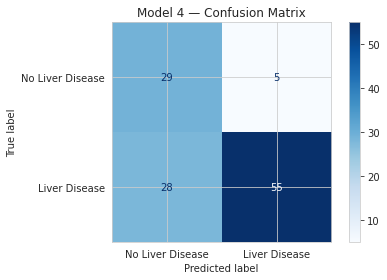

                  precision    recall  f1-score   support

No Liver Disease       0.51      0.85      0.64        34
   Liver Disease       0.92      0.66      0.77        83

        accuracy                           0.72       117
       macro avg       0.71      0.76      0.70       117
    weighted avg       0.80      0.72      0.73       117



In [50]:
# Create confusion matrix
y_pred_m4 = pipe_m4.predict(X_test)
cm_m4 = confusion_matrix(y_test, y_pred_m4)
disp_m4 = ConfusionMatrixDisplay(confusion_matrix=cm_m4, display_labels=['No Liver Disease', 'Liver Disease'])
disp_m4.plot(cmap='Blues')
plt.title('Model 4 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m4, target_names=['No Liver Disease', 'Liver Disease']))

The adjustments we made actually worsened the model by a lot because it significantly increased the number of false negatives. However, it did drastically improve the number of true negatives. But if we are dealing with liver patients, it's very risky to misclassify patients for not having liver disease when they actually do.

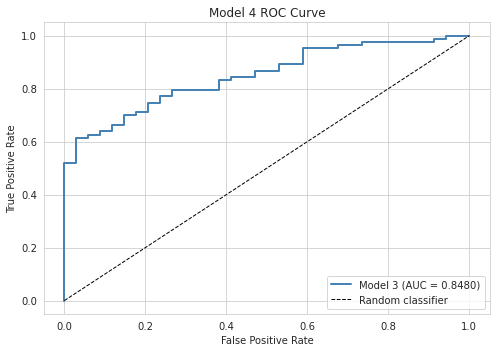

Model 4 ROC-AUC: 0.8320


In [51]:
# ROC Curve

y_proba_m4 = pipe_m4.predict_proba(X_test)[:, 1]
fpr_m4, tpr_m4, thresholds = roc_curve(y_test, y_proba_m4)
auc_m4 = roc_auc_score(y_test, y_proba_m4)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m4, tpr_m4, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m4:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 4 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 4 ROC-AUC: {auc_m3:.4f}")

The ROC score for this model is still lower than Model 2.

# Interpretation

Out of the four logistic regression models, Model 2 (log-transformed variables, no elimination of any features) had the best ROC score of 0.8455. While it is not perfect, it falls into the "Good" category (0.8-0.9). This is impressive for a relatively small data set. The best way to improve the model would be to have more data for it to train on, but for a small data set, it is a good score. It is also the model with the fewest number of false negatives, which is good because that is what we want to reduce. It's better to have more false positives (accidentally diagnosing someone with liver disease when they actually don't have it) than to have more false negatives (accidentally saying someone does not have liver disease when they actually do) in the context of disease data. It puts fewer lives at risk. 

In [52]:
# Find the best threshold by maximizing sensitivity (recall for positive class)
y_proba_m2 = pipe_m2.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, thresholds = roc_curve(y_test, y_proba_m2)

# Look at sensitivity/specificity across thresholds
threshold_df = pd.DataFrame({
    'threshold': thresholds,
    'sensitivity': tpr_m2,        # True positive rate (catches liver disease)
    'specificity': 1 - fpr_m2     # True negative rate (correctly clears healthy patients)
})
print(threshold_df)

    threshold  sensitivity  specificity
0    1.996964     0.000000     1.000000
1    0.996964     0.012048     1.000000
2    0.827009     0.506024     1.000000
3    0.825248     0.506024     0.970588
4    0.775860     0.614458     0.970588
5    0.771794     0.614458     0.941176
6    0.760214     0.638554     0.941176
7    0.748320     0.638554     0.882353
8    0.714989     0.674699     0.882353
9    0.714720     0.674699     0.852941
10   0.691362     0.698795     0.852941
11   0.690798     0.698795     0.823529
12   0.689359     0.710843     0.823529
13   0.687475     0.710843     0.794118
14   0.670783     0.746988     0.794118
15   0.667853     0.746988     0.764706
16   0.666136     0.759036     0.764706
17   0.650925     0.759036     0.735294
18   0.646250     0.783133     0.735294
19   0.639556     0.783133     0.705882
20   0.637124     0.795181     0.705882
21   0.619994     0.795181     0.647059
22   0.611428     0.807229     0.647059
23   0.605474     0.807229     0.617647


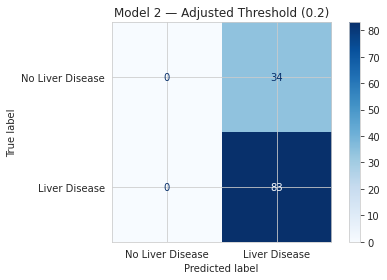

                  precision    recall  f1-score   support

No Liver Disease       0.00      0.00      0.00        34
   Liver Disease       0.71      1.00      0.83        83

        accuracy                           0.71       117
       macro avg       0.35      0.50      0.41       117
    weighted avg       0.50      0.71      0.59       117



/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

In [55]:
THRESHOLD = 0.2 # adjust based on what the table above shows

y_pred_m2_adjusted = (y_proba_m2 >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred_m2_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Liver Disease', 'Liver Disease'])
disp.plot(cmap='Blues')
plt.title(f'Model 2 — Adjusted Threshold ({THRESHOLD})')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2_adjusted, target_names=['No Liver Disease', 'Liver Disease']))